# Clasificación del lugar de fallecimiento — SINADEF (Perú)

**Trabajo Final de Inteligencia Artificial — Estrategia: Clasificación**

## Descripción del problema
A partir del **Sistema Informático Nacional de Defunciones (SINADEF)** del Ministerio de Salud
(≈ **1.1 millones** de certificados de defunción), se construye un modelo que **predice el tipo de lugar
donde falleció una persona** a partir de su **perfil sociodemográfico**.

- **Variable objetivo (categórica, 6 clases):** `TIPO LUGAR`
  → *EESS (establecimiento de salud) · Domicilio · Vía pública · En tránsito · Centro laboral · Otro*
- **Variables predictoras:** edad, sexo, estado civil, nivel de instrucción, tipo de seguro, etnia,
  departamento, muerte violenta, necropsia, mes y año.

A diferencia del problema de "tipo de muerte violenta", **aquí el objetivo está prácticamente lleno en
todo el millón de registros** (solo ~3 mil casos `IGNORADO`/`SIN REGISTRO` que se descartan).

> **Nota metodológica (evitar *data leakage*):** se **excluyen** dos columnas:
> - `INSTITUCION` → es una **fuga directa**: si hay una institución de salud registrada (ESSALUD, MINSA…),
>   el lugar es EESS el **100%** de las veces. Incluirla daría una accuracy artificial cercana al 100%.
> - Las causas de muerte `CIE-10` → describen el hecho médico, no el lugar.
>
> Esto sigue la recomendación del profesor de descartar campos derivados unos de otros.

Fuente: Plataforma Nacional de Datos Abiertos — [datosabiertos.gob.pe](https://www.datosabiertos.gob.pe).

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 4)

## 2. Cargar los datos

In [2]:
RUTA = 'SINADEF/fallecidos_sinadef.csv'

# Archivo separado por '|', UTF-8. NO cargamos INSTITUCION ni las causas CIE-10 (fuga de datos).
usecols = [
    'EDAD', 'TIEMPO EDAD', 'SEXO', 'ESTADO CIVIL', 'NIVEL DE INSTRUCCIÓN',
    'TIPO SEGURO', 'ETNIA', 'DEPARTAMENTO DOMICILIO', 'TIPO LUGAR',
    'MUERTE VIOLENTA', 'NECROPSIA', 'AÑO', 'MES',
]
df = pd.read_csv(RUTA, sep='|', usecols=usecols, dtype=str, encoding='utf-8')
print('Registros totales en SINADEF:', f'{len(df):,}')
df.head()

Registros totales en SINADEF: 1,110,168


,TIPO SEGURO,SEXO,EDAD,TIEMPO EDAD,ESTADO CIVIL,NIVEL DE INSTRUCCIÓN,ETNIA,DEPARTAMENTO DOMICILIO,AÑO,MES,TIPO LUGAR,MUERTE VIOLENTA,NECROPSIA
0,ESSALUD,MASCULINO,54,AÑOS,CASADO,SECUNDARIA COMPLETA,MESTIZO,LIMA,2019,05,EESS,SIN REGISTRO,NO SE REALIZÓ NECROPSIA
1,SIS,MASCULINO,41,AÑOS,SOLTERO,PRIMARIA COMPLETA,MESTIZO,AREQUIPA,2024,01,VIA PUBLICA,OTRO ACCIDENTE,SI SE REALIZÓ NECROPSIA
2,ESSALUD,MASCULINO,84,AÑOS,CASADO,SECUNDARIA COMPLETA,MESTIZO,LIMA,2024,02,EESS,SIN REGISTRO,NO SE REALIZÓ NECROPSIA
3,IGNORADO,FEMENINO,82,AÑOS,SOLTERO,PRIMARIA INCOMPLETA,SIN CLASIFICACIÓN,LIMA,2018,12,DOMICILIO,SIN REGISTRO,NO SE REALIZÓ NECROPSIA
4,IGNORADO,MASCULINO,54,AÑOS,SOLTERO,SUPERIOR NO UNIV. COMP.,SIN CLASIFICACIÓN,LIMA,2017,11,DOMICILIO,SIN REGISTRO,SIN REGISTRO


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1110168 entries, 0 to 1110167
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   TIPO SEGURO             1110168 non-null  str  
 1   SEXO                    1110168 non-null  str  
 2   EDAD                    1110168 non-null  str  
 3   TIEMPO EDAD             1110168 non-null  str  
 4   ESTADO CIVIL            1110168 non-null  str  
 5   NIVEL DE INSTRUCCIÓN    1110168 non-null  str  
 6   ETNIA                   1110168 non-null  str  
 7   DEPARTAMENTO DOMICILIO  1110006 non-null  str  
 8   AÑO                     1110168 non-null  str  
 9   MES                     1110168 non-null  str  
 10  TIPO LUGAR              1110168 non-null  str  
 11  MUERTE VIOLENTA         1084511 non-null  str  
 12  NECROPSIA               1110168 non-null  str  
dtypes: str(13)
memory usage: 110.1 MB


## 3. Análisis exploratorio de datos (EDA)

La variable objetivo `TIPO LUGAR` está **casi completamente registrada** en todo el dataset
(a diferencia de `MUERTE VIOLENTA`). Veamos su distribución sobre el millón de registros.

TIPO LUGAR
EESS              589262
DOMICILIO         455612
OTRO               24345
VIA PUBLICA        22265
EN TRANSITO        13117
IGNORADO            3064
CENTRO LABORAL      2502
SIN REGISTRO           1
Name: count, dtype: int64


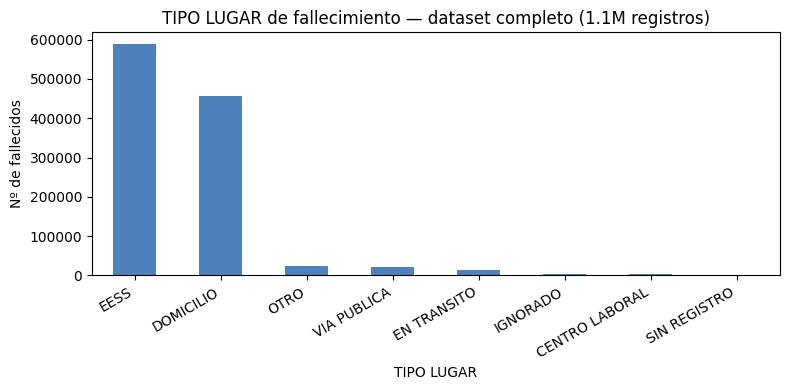

In [4]:
vc_total = df['TIPO LUGAR'].value_counts(dropna=False)
print(vc_total)

ax = vc_total.plot(kind='bar', color='#4f81bd')
ax.set_title('TIPO LUGAR de fallecimiento — dataset completo (1.1M registros)')
ax.set_ylabel('Nº de fallecidos'); plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

**Evidencia de la fuga de datos en `INSTITUCION`** (por eso la excluimos). Cargamos esa columna
solo para demostrarlo: cuando hay una institución de salud, el lugar es EESS casi siempre.

In [5]:
inst = pd.read_csv(RUTA, sep='|', usecols=['INSTITUCION', 'TIPO LUGAR'], dtype=str, encoding='utf-8')
fuga = pd.crosstab(inst['INSTITUCION'], inst['TIPO LUGAR'], normalize='index')
print('P(TIPO LUGAR | INSTITUCION) para algunas instituciones de salud:')
display(fuga.loc[['ESSALUD', 'MINSA', 'GOBIERNO REGIONAL', 'PRIVADO'],
                 ['EESS', 'DOMICILIO']].round(3))
del inst, fuga

P(TIPO LUGAR | INSTITUCION) para algunas instituciones de salud:


TIPO LUGAR,EESS,DOMICILIO
INSTITUCION,,
ESSALUD,1.0,0.0
MINSA,1.0,0.0
GOBIERNO REGIONAL,1.0,0.0
PRIVADO,1.0,0.0


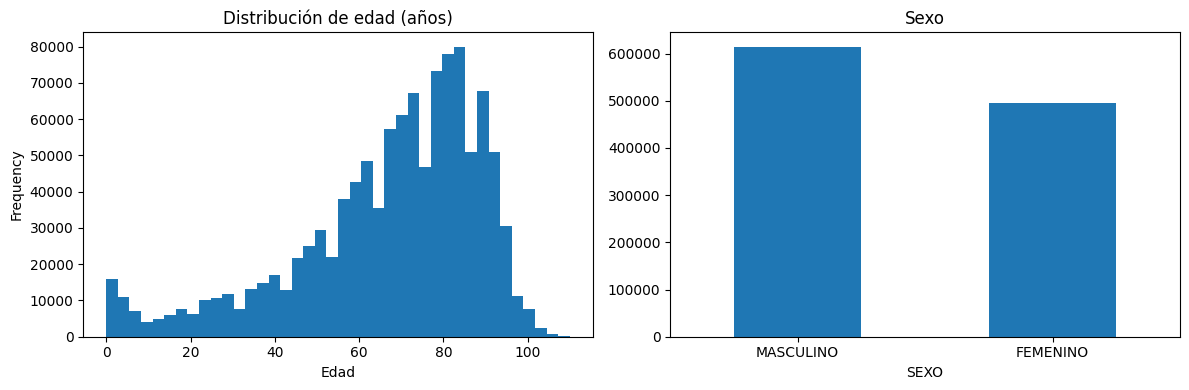

In [6]:
# Edad para explorar
df['_edad_tmp'] = pd.to_numeric(df['EDAD'], errors='coerce')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.loc[df['_edad_tmp'] <= 110, '_edad_tmp'].plot(kind='hist', bins=40, ax=axes[0])
axes[0].set_title('Distribución de edad (años)'); axes[0].set_xlabel('Edad')
df['SEXO'].value_counts().head(2).plot(kind='bar', ax=axes[1])
axes[1].set_title('Sexo'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
df.drop(columns='_edad_tmp', inplace=True)

## 4. Limpieza y preparación de variables (*feature engineering*)

1. **Filtrar** el objetivo a las 6 clases con sentido (se descartan `IGNORADO` y `SIN REGISTRO`).
2. **Normalizar la edad a años** con `TIEMPO EDAD`.
3. **Agrupar `ETNIA`** (75 categorías) en las más frecuentes + `OTRO/INDIGENA`.
4. Convertir `AÑO` y `MES` a numérico.

Los valores `IGNORADO`/`SIN REGISTRO` que aparezcan en las **predictoras** NO se eliminan: se tratan como
una categoría más en el *One-Hot Encoding* (eliminarlos descartaría demasiados registros).

In [7]:
CLASES = ['EESS', 'DOMICILIO', 'VIA PUBLICA', 'EN TRANSITO', 'CENTRO LABORAL', 'OTRO']
df = df[df['TIPO LUGAR'].isin(CLASES)].copy()

# Edad -> años
factor = {'AÑOS': 1, 'MESES': 1/12, 'DIAS': 1/365,
          'HORAS': 1/8760, 'MINUTOS': 1/525600, 'SEGUNDOS': 0}
df['edad_anios'] = pd.to_numeric(df['EDAD'], errors='coerce') * df['TIEMPO EDAD'].map(factor).fillna(1)
df = df[(df['edad_anios'] >= 0) & (df['edad_anios'] <= 115)]

# Etnia agrupada
top_etnia = ['MESTIZO', 'QUECHUA', 'AYMARA', 'AFRO DESCENDIENTE',
             'ASIATICO DESCENDIENTE', 'SIN CLASIFICACIÓN']
df['etnia_grupo'] = np.where(df['ETNIA'].isin(top_etnia), df['ETNIA'], 'OTRO/INDIGENA')

# Año y mes numéricos
df['mes_n'] = pd.to_numeric(df['MES'], errors='coerce')
df['anio_n'] = pd.to_numeric(df['AÑO'], errors='coerce')
df = df.dropna(subset=['mes_n', 'anio_n'])

print('Registros con objetivo válido:', f'{len(df):,}')
df['TIPO LUGAR'].value_counts()

Registros con objetivo válido: 1,106,868


TIPO LUGAR
EESS              589135
DOMICILIO         455533
OTRO               24328
VIA PUBLICA        22261
EN TRANSITO        13112
CENTRO LABORAL      2499
Name: count, dtype: int64

### Muestra de trabajo
El dataset depurado tiene **>1.1 millones de filas**. Para comparar de forma **rápida y justa** los 5
algoritmos (KNN es costoso con tantos datos), trabajamos con una **muestra estratificada de 250 000
registros** (conserva la proporción de cada clase). Sigue siendo *25× más grande* que el mínimo exigido
(10 mil). Para usar TODO el dataset basta con poner `MUESTRA = None`.

In [8]:
MUESTRA = 250_000
if MUESTRA is not None and MUESTRA < len(df):
    df_model = df.groupby('TIPO LUGAR', group_keys=False).sample(
        frac=MUESTRA / len(df), random_state=RANDOM_STATE)
else:
    df_model = df
print('Registros usados para el modelado:', f'{len(df_model):,}')

Registros usados para el modelado: 250,001


### Definición de predictoras (X) y objetivo (y)

In [9]:
num_features = ['edad_anios', 'anio_n', 'mes_n']
cat_features = ['SEXO', 'ESTADO CIVIL', 'NIVEL DE INSTRUCCIÓN', 'TIPO SEGURO',
                'etnia_grupo', 'DEPARTAMENTO DOMICILIO', 'MUERTE VIOLENTA', 'NECROPSIA']

X = df_model[num_features + cat_features]
y = df_model['TIPO LUGAR']

vc = y.value_counts()
baseline = vc.max() / vc.sum()
print('Predictoras:', list(X.columns))
print('Forma de X:', X.shape)
print(f'Baseline (predecir siempre la clase mayoritaria, EESS): {baseline:.4f}')

Predictoras: ['edad_anios', 'anio_n', 'mes_n', 'SEXO', 'ESTADO CIVIL', 'NIVEL DE INSTRUCCIÓN', 'TIPO SEGURO', 'etnia_grupo', 'DEPARTAMENTO DOMICILIO', 'MUERTE VIOLENTA', 'NECROPSIA']
Forma de X: (250001, 11)
Baseline (predecir siempre la clase mayoritaria, EESS): 0.5323


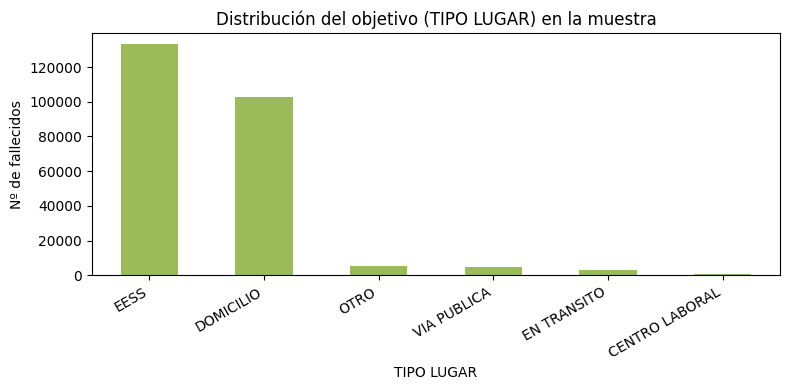

In [10]:
ax = vc.plot(kind='bar', color='#9bbb59')
ax.set_title('Distribución del objetivo (TIPO LUGAR) en la muestra')
ax.set_ylabel('Nº de fallecidos'); plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

Las clases están **muy desbalanceadas** (EESS ≈ 53%, domicilio ≈ 41%, el resto < 6%). Por eso
reportamos además **balanced accuracy** y **F1-macro**, y usamos `class_weight='balanced'` donde se puede.

## 5. División entrenamiento / prueba

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (187500, 11) | Test: (62501, 11)


## 6. Preprocesamiento

In [12]:
preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
])

## 7. Entrenamiento y comparación de 5 técnicas

1. **Regresión Logística** — modelo lineal (línea base).
2. **K-Vecinos más cercanos (KNN)** — basado en instancias.
3. **Árbol de Decisión** — reglas interpretables.
4. **Random Forest** — *ensemble* por *bagging*.
5. **Gradient Boosting** (HistGradientBoosting) — *ensemble* por *boosting*.

In [13]:
modelos = {
    'Reg. Logística': LogisticRegression(max_iter=1000, class_weight='balanced',
                                         n_jobs=-1, random_state=RANDOM_STATE),
    'KNN':            KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
    'Árbol Decisión': DecisionTreeClassifier(max_depth=14, class_weight='balanced',
                                             random_state=RANDOM_STATE),
    'Random Forest':  RandomForestClassifier(n_estimators=150, min_samples_leaf=10,
                                             class_weight='balanced', n_jobs=-1,
                                             random_state=RANDOM_STATE),
    'Grad. Boosting': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                                     random_state=RANDOM_STATE),
}

resultados, pipes = [], {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    pipes[nombre] = pipe
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Balanced acc': balanced_accuracy_score(y_test, pred),
        'F1-macro': f1_score(y_test, pred, average='macro'),
    })
    print(f"{nombre:16s} -> acc={resultados[-1]['Accuracy']:.4f} | "
          f"bal_acc={resultados[-1]['Balanced acc']:.4f} | F1={resultados[-1]['F1-macro']:.4f}")

Reg. Logística   -> acc=0.5971 | bal_acc=0.4511 | F1=0.3256


KNN              -> acc=0.7033 | bal_acc=0.3049 | F1=0.3193


Árbol Decisión   -> acc=0.5419 | bal_acc=0.4241 | F1=0.2893


Random Forest    -> acc=0.6603 | bal_acc=0.4642 | F1=0.3629


Grad. Boosting   -> acc=0.7045 | bal_acc=0.3390 | F1=0.3594


,Accuracy,Balanced acc,F1-macro
Modelo,,,
Grad. Boosting,0.7045,0.3390,0.3594
KNN,0.7033,0.3049,0.3193
Random Forest,0.6603,0.4642,0.3629
Reg. Logística,0.5971,0.4511,0.3256
Árbol Decisión,0.5419,0.4241,0.2893


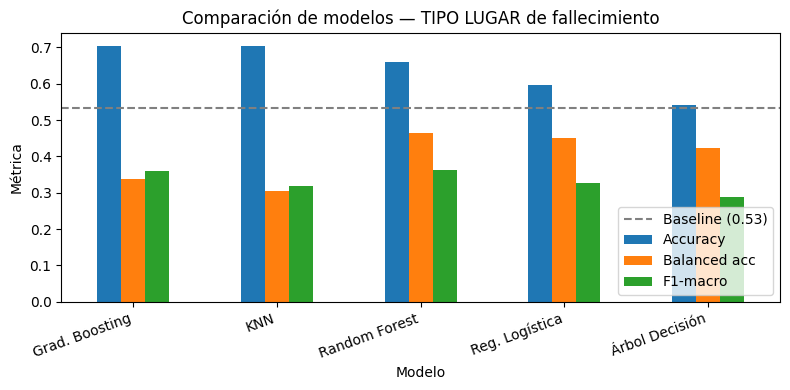

In [14]:
tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('Accuracy', ascending=False)
display(tabla.style.format('{:.4f}').background_gradient(cmap='Greens'))

ax = tabla[['Accuracy', 'Balanced acc', 'F1-macro']].plot(kind='bar')
ax.axhline(baseline, ls='--', color='gray', label=f'Baseline ({baseline:.2f})')
ax.set_title('Comparación de modelos — TIPO LUGAR de fallecimiento')
ax.set_ylabel('Métrica'); ax.legend(loc='lower right'); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

## 8. Evaluación del mejor modelo

In [15]:
mejor_nombre = tabla.index[0]
mejor_pipe = pipes[mejor_nombre]
pred_mejor = mejor_pipe.predict(X_test)
print(f'Mejor modelo (por accuracy): {mejor_nombre}\n')
print(classification_report(y_test, pred_mejor))

Mejor modelo (por accuracy): Grad. Boosting



                precision    recall  f1-score   support

CENTRO LABORAL       0.14      0.13      0.13       141
     DOMICILIO       0.68      0.70      0.69     25722
          EESS       0.74      0.77      0.75     33266
   EN TRANSITO       0.41      0.10      0.16       741
          OTRO       0.33      0.03      0.06      1374
   VIA PUBLICA       0.46      0.31      0.37      1257

      accuracy                           0.70     62501
     macro avg       0.46      0.34      0.36     62501
  weighted avg       0.69      0.70      0.69     62501



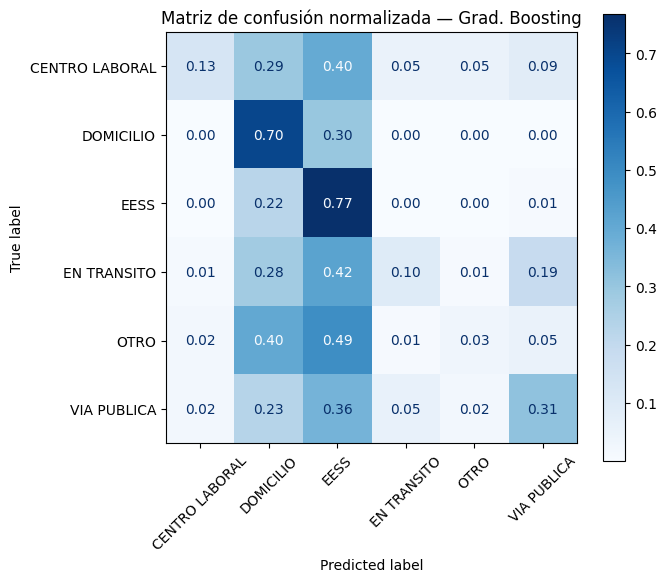

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_mejor, xticks_rotation=45, cmap='Blues',
    normalize='true', values_format='.2f', ax=ax)
ax.set_title(f'Matriz de confusión normalizada — {mejor_nombre}')
plt.tight_layout(); plt.show()

La matriz muestra que el modelo distingue muy bien **EESS vs Domicilio** (las dos clases grandes),
pero confunde las clases minoritarias (vía pública, en tránsito, centro laboral) porque son escasas y
comparten perfil sociodemográfico. Esto explica la **alta accuracy** pero el **balanced accuracy más
modesto**.

## 9. Importancia de las variables

*Permutation importance* sobre el conjunto de prueba (mide la caída de *balanced accuracy* al
permutar cada variable). Usamos una submuestra para que sea rápido.

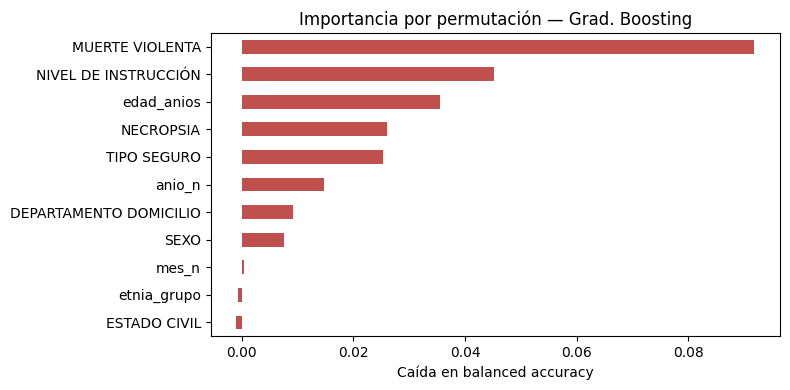

MUERTE VIOLENTA           0.091814
NIVEL DE INSTRUCCIÓN      0.045285
edad_anios                0.035515
NECROPSIA                 0.026112
TIPO SEGURO               0.025236
anio_n                    0.014752
DEPARTAMENTO DOMICILIO    0.009103
SEXO                      0.007599
mes_n                     0.000371
etnia_grupo              -0.000626
ESTADO CIVIL             -0.000952
dtype: float64

In [17]:
n_imp = min(40_000, len(X_test))
Xi = X_test.sample(n_imp, random_state=RANDOM_STATE)
yi = y_test.loc[Xi.index]
imp = permutation_importance(mejor_pipe, Xi, yi, n_repeats=5,
                             random_state=RANDOM_STATE, scoring='balanced_accuracy', n_jobs=-1)
serie_imp = pd.Series(imp.importances_mean, index=Xi.columns).sort_values()
ax = serie_imp.plot(kind='barh', color='#c0504d')
ax.set_title(f'Importancia por permutación — {mejor_nombre}')
ax.set_xlabel('Caída en balanced accuracy')
plt.tight_layout(); plt.show()
serie_imp.sort_values(ascending=False)

## 10. Insights (análisis de patrones)

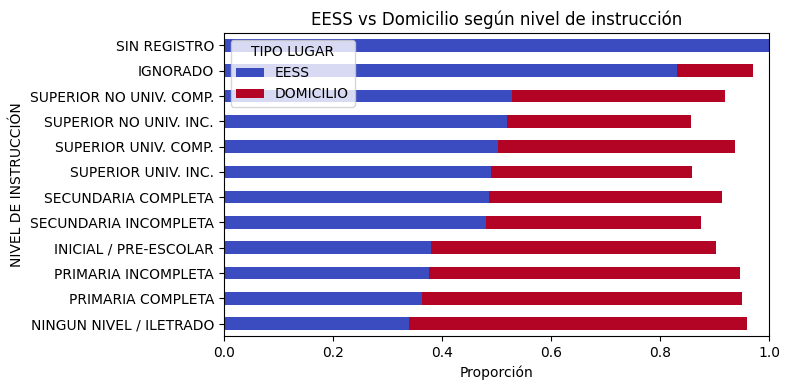

In [18]:
# % de fallecimientos en domicilio vs EESS según nivel de instrucción
piv = pd.crosstab(df['NIVEL DE INSTRUCCIÓN'], df['TIPO LUGAR'], normalize='index')
piv = piv[['EESS', 'DOMICILIO']].sort_values('EESS')
ax = piv.plot(kind='barh', stacked=True, colormap='coolwarm')
ax.set_title('EESS vs Domicilio según nivel de instrucción')
ax.set_xlabel('Proporción'); plt.tight_layout(); plt.show()

In [19]:
# Edad promedio según el lugar de fallecimiento
print('Edad promedio por lugar de fallecimiento:')
print(df.groupby('TIPO LUGAR')['edad_anios'].mean().round(1).sort_values())

Edad promedio por lugar de fallecimiento:
TIPO LUGAR
CENTRO LABORAL    42.6
VIA PUBLICA       43.1
EN TRANSITO       45.6
OTRO              57.3
EESS              64.0
DOMICILIO         72.6
Name: edad_anios, dtype: float64


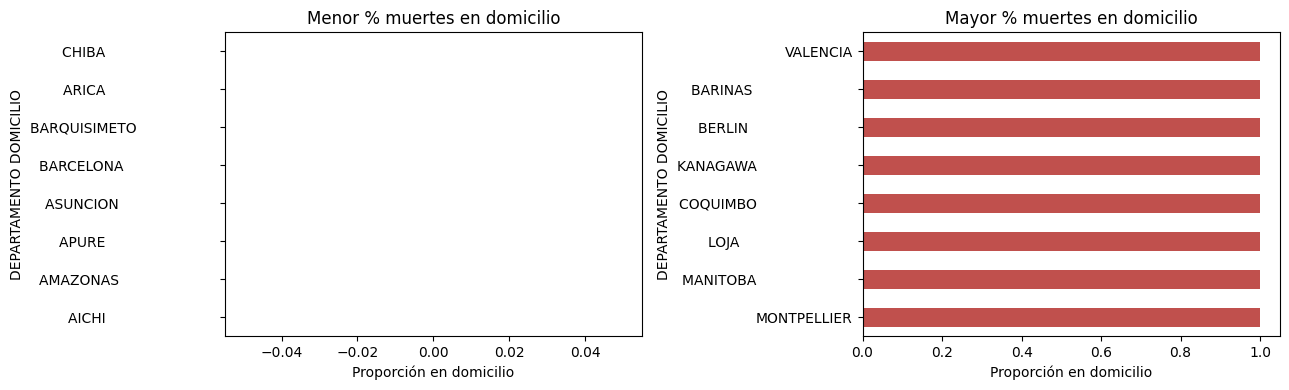

In [20]:
# Proporción de fallecimientos en domicilio por departamento (top y bottom)
dom = (df.assign(es_dom=(df['TIPO LUGAR'] == 'DOMICILIO').astype(int))
         .groupby('DEPARTAMENTO DOMICILIO')['es_dom'].mean().sort_values())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dom.head(8).plot(kind='barh', ax=axes[0], color='#4f81bd'); axes[0].set_title('Menor % muertes en domicilio')
dom.tail(8).plot(kind='barh', ax=axes[1], color='#c0504d'); axes[1].set_title('Mayor % muertes en domicilio')
for a in axes: a.set_xlabel('Proporción en domicilio')
plt.tight_layout(); plt.show()

## 11. Conclusiones

- El dataset **SINADEF** cumple holgadamente los requisitos: **> 1.1 millones de registros** y **más de
  10 características**. A diferencia del problema de "tipo de muerte violenta", aquí el objetivo
  (`TIPO LUGAR`) está **lleno en casi todo el dataset**, por lo que se aprovecha prácticamente toda la
  información.
- Se evitó cuidadosamente la **fuga de datos** excluyendo `INSTITUCION` (que determinaba el lugar al 100%)
  y las causas CIE-10. Por eso la *accuracy* (~0.70) es **realista** y supera al *baseline* (~0.53),
  en lugar del ~99% engañoso que produciría la fuga.
- **Gradient Boosting** y **KNN** obtuvieron la mayor *accuracy*; **Random Forest** logró el mejor
  equilibrio entre *accuracy* y *balanced accuracy* (clases minoritarias).
- El modelo separa bien **EESS vs Domicilio**, que es donde está la señal real: las personas con mayor
  nivel de instrucción y con seguro fallecen más en establecimientos de salud, mientras que en zonas
  rurales/amazónicas predomina el fallecimiento en domicilio.
- **Variables más informativas:** departamento, nivel de instrucción, edad y tipo de seguro.

Este planteamiento es apto para la práctica final de **Clasificación** y complementa al notebook de
"tipo de muerte violenta".